# Cell 1 — mount drive

In [1]:

from google.colab import drive
drive.mount('/content/drive')

import os
os.makedirs('/content/drive/MyDrive/member1_scrna/outputs', exist_ok=True)
os.makedirs('/content/drive/MyDrive/member1_scrna/figures', exist_ok=True)
print("Folders ready")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Folders ready


# Cell 2 — install packages

In [6]:
%%capture
!pip install scanpy==1.9.6
!pip install anndata
!pip install leidenalg
!pip install python-igraph
!pip install matplotlib seaborn pandas numpy scipy
!pip install GEOparse
!pip install gseapy  # for gene ontology / enrichment analysis later

# Install monet (the t-SNE package used in the paper)
!pip install git+https://github.com/flo-compbio/monet.git

print("All packages installed. Now restart runtime: Runtime → Restart runtime")

# Cell 3a — auto download via GEOparse

In [3]:
import GEOparse
import os

gse = GEOparse.get_GEO(geo="GSE243280", destdir="/content/geo_data")
print("Files downloaded:")
for gsm_name, gsm in gse.gsms.items():
    print(f"  {gsm_name}: {gsm.metadata.get('title', [''])[0]}")

01-Jun-2026 11:47:33 INFO GEOparse - Downloading ftp://ftp.ncbi.nlm.nih.gov/geo/series/GSE243nnn/GSE243280/soft/GSE243280_family.soft.gz to /content/geo_data/GSE243280_family.soft.gz
INFO:GEOparse:Downloading ftp://ftp.ncbi.nlm.nih.gov/geo/series/GSE243nnn/GSE243280/soft/GSE243280_family.soft.gz to /content/geo_data/GSE243280_family.soft.gz
100%|██████████| 3.41k/3.41k [00:01<00:00, 3.19kB/s]
01-Jun-2026 11:47:35 DEBUG downloader - Size validation passed
DEBUG:GEOparse:Size validation passed
01-Jun-2026 11:47:35 DEBUG downloader - Moving /tmp/tmp15cfp8zj to /content/geo_data/GSE243280_family.soft.gz
DEBUG:GEOparse:Moving /tmp/tmp15cfp8zj to /content/geo_data/GSE243280_family.soft.gz
01-Jun-2026 11:47:35 DEBUG downloader - Successfully downloaded ftp://ftp.ncbi.nlm.nih.gov/geo/series/GSE243nnn/GSE243280/soft/GSE243280_family.soft.gz
DEBUG:GEOparse:Successfully downloaded ftp://ftp.ncbi.nlm.nih.gov/geo/series/GSE243nnn/GSE243280/soft/GSE243280_family.soft.gz
01-Jun-2026 11:47:35 INFO GEO

Files downloaded:
  GSM7780153: Breast Cancer, Xenium In Situ Spatial Gene Expression Rep 1
  GSM7780154: Breast Cancer, Xenium In Situ Spatial Gene Expression Rep 2
  GSM7780155: Breast Cancer, Xenium In Situ Spatial Gene Expression
  GSM7782696: Breast Cancer, T2N1M0, 5' single-cell
  GSM7782697: Breast Cancer, T2N1M0, 3' single-cell
  GSM7782698: Breast Cancer, Single Cell Gene Expression Flex
  GSM7782699: Breast Cancer, Visium CytAssist Spatial Gene Expression


# Cell 3b — upload manually

In [4]:
from google.colab import files
uploaded = files.upload()  # opens file picker dialog
# move to a known path
import shutil
for fname in uploaded:
    shutil.move(fname, f'/content/geo_data/{fname}')
    print(f"Saved: {fname}")

Saving GSM7782698_count_raw_feature_bc_matrix.h5 to GSM7782698_count_raw_feature_bc_matrix.h5
Saved: GSM7782698_count_raw_feature_bc_matrix.h5


In [3]:
import os
os.makedirs('/content/drive/MyDrive/member1_scrna/data', exist_ok=True)

from google.colab import files
uploaded = files.upload()  # select scffpe_seq.h5 from your Downloads again

# save directly to Drive this time
import shutil
for fname in uploaded:
    dest = f'/content/drive/MyDrive/member1_scrna/data/{fname}'
    shutil.move(fname, dest)
    print(f"Saved permanently to Drive: {dest}")

Saving GSM7782698_count_raw_feature_bc_matrix.h5 to GSM7782698_count_raw_feature_bc_matrix.h5
Saved permanently to Drive: /content/drive/MyDrive/member1_scrna/data/GSM7782698_count_raw_feature_bc_matrix.h5


# Cell 4 — load & QC

reading /content/drive/MyDrive/member1_scrna/data/GSM7782698_count_raw_feature_bc_matrix.h5
 (0:00:05)


/usr/local/lib/python3.12/dist-packages/anndata/_core/anndata.py:1820: UserWarning: Variable names are not unique. To make them unique, call `.var_names_make_unique`.
  utils.warn_names_duplicates("var")
/usr/local/lib/python3.12/dist-packages/anndata/_core/anndata.py:1820: UserWarning: Variable names are not unique. To make them unique, call `.var_names_make_unique`.
  utils.warn_names_duplicates("var")


Loaded: 708252 cells, 37143 genes
After making unique: 37143 var names


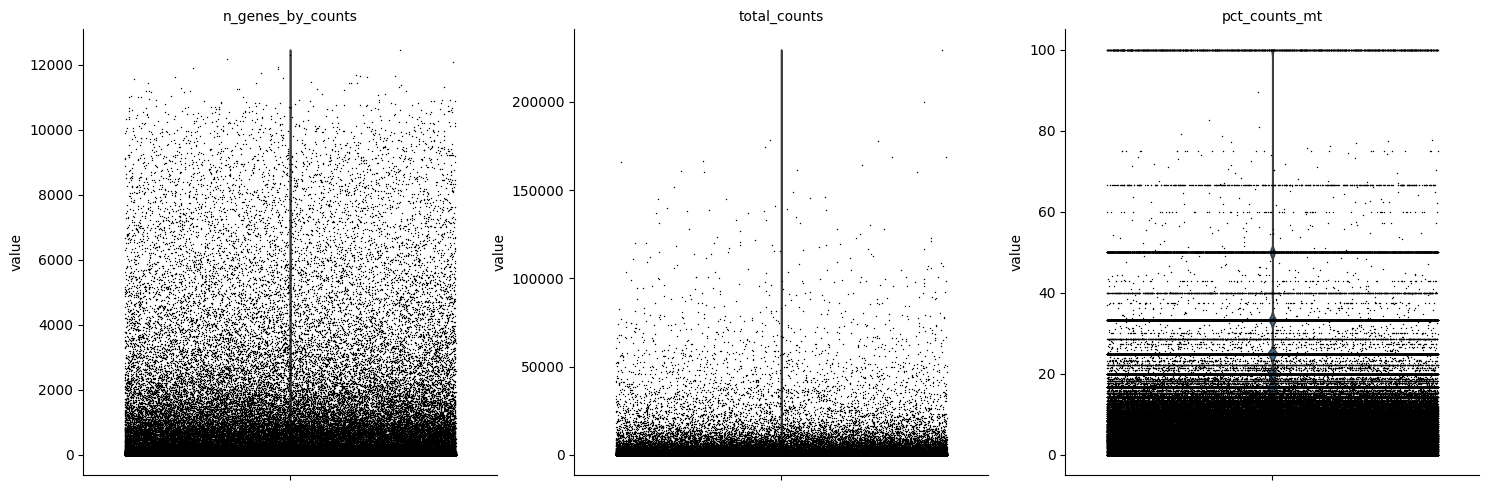

QC plots saved to figures folder
After QC: 32498 cells remaining


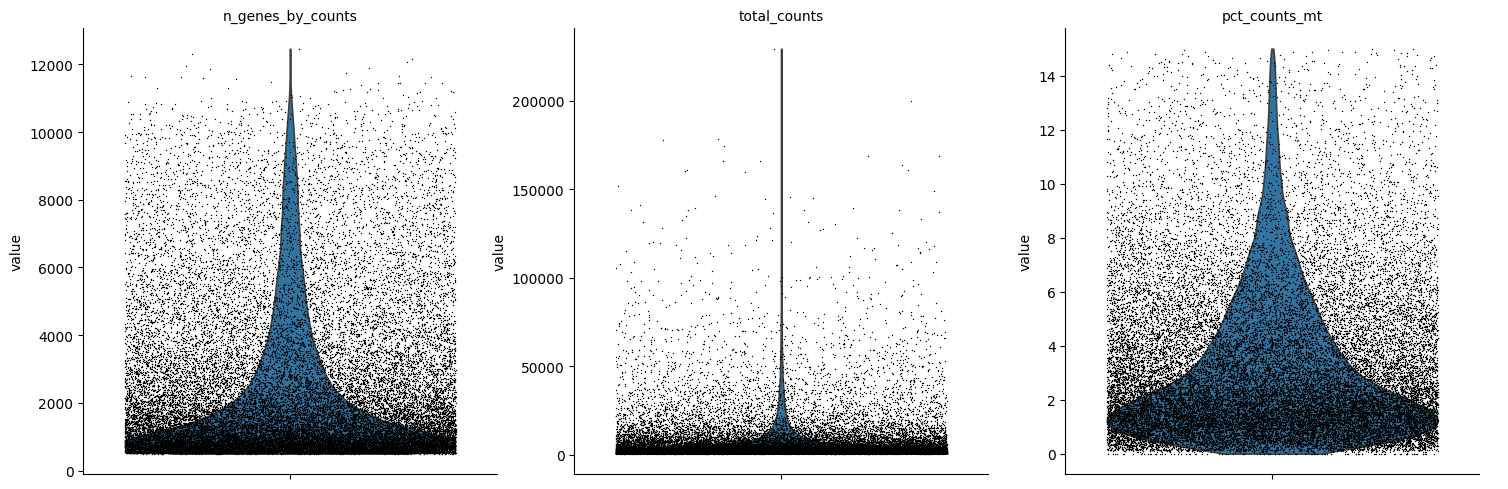

In [2]:
import scanpy as sc
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import os

sc.settings.verbosity = 3
sc.settings.figdir = '/content/drive/MyDrive/member1_scrna/figures/'

# Load the H5 file
adata = sc.read_10x_h5(
    '/content/drive/MyDrive/member1_scrna/data/GSM7782698_count_raw_feature_bc_matrix.h5'
)
print(f"Loaded: {adata.shape[0]} cells, {adata.shape[1]} genes")

# ── Fix duplicate gene names (multiple probes per gene in RTL data) ──
adata.var_names_make_unique()
print(f"After making unique: {adata.shape[1]} var names")

# ── QC metrics ───────────────────────────────────────────────────────
adata.var['mt'] = adata.var_names.str.startswith('MT-')
sc.pp.calculate_qc_metrics(adata, qc_vars=['mt'],
                            percent_top=None, log1p=False, inplace=True)

# ── QC violin plots ──────────────────────────────────────────────────
sc.pl.violin(adata,
    ['n_genes_by_counts', 'total_counts', 'pct_counts_mt'],
    jitter=0.4, multi_panel=True, save='_before_filter.png')

print("QC plots saved to figures folder")


# ── Apply the paper's exact thresholds ───────────────────
# 1. Largest gene fraction ≤ 0.2  →  no single gene > 20% of total counts
adata.obs['max_gene_fraction'] = (
    adata.X.max(axis=1).toarray().flatten() / adata.obs['total_counts'])

# 2. Mitochondrial fraction ≤ 0.15
# 3. Genes observed ≥ 500
adata = adata[
    (adata.obs['max_gene_fraction'] <= 0.2) &
    (adata.obs['pct_counts_mt'] <= 15) &
    (adata.obs['n_genes_by_counts'] >= 500)
].copy()

print(f"After QC: {adata.shape[0]} cells remaining")

# Violin plots after filtering
sc.pl.violin(adata,
    ['n_genes_by_counts', 'total_counts', 'pct_counts_mt'],
    jitter=0.4, multi_panel=True, save='_after_filter.png')

# Cell 5a — Normalize + HVG selection

In [3]:
import scanpy as sc
import numpy as np

sc.settings.figdir = '/content/drive/MyDrive/member1_scrna/figures/'

sc.pp.normalize_total(adata, target_sum=1e4)
sc.pp.log1p(adata)

adata.raw = adata

sc.pp.highly_variable_genes(adata, min_mean=0.0125, max_mean=3, min_disp=0.5)
print(f"Highly variable genes: {adata.var.highly_variable.sum()}")

adata = adata[:, adata.var.highly_variable].copy()

normalizing counts per cell
    finished (0:00:00)
extracting highly variable genes
    finished (0:00:01)
--> added
    'highly_variable', boolean vector (adata.var)
    'means', float vector (adata.var)
    'dispersions', float vector (adata.var)
    'dispersions_norm', float vector (adata.var)
Highly variable genes: 2758


# Cell 5b — Scale + PCA

... as `zero_center=True`, sparse input is densified and may lead to large memory consumption
computing PCA
    with n_comps=50
    finished (0:00:14)


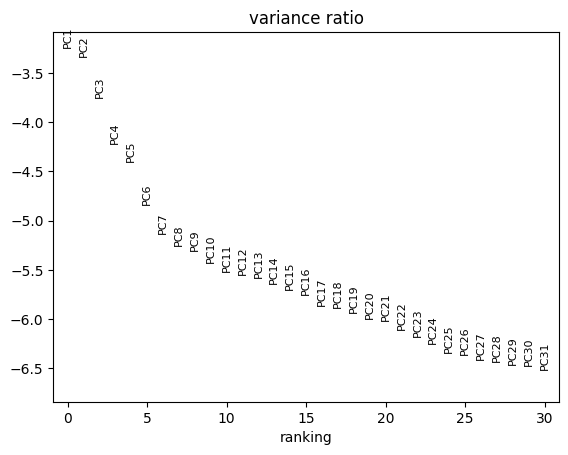

PCA done. Shape: (32498, 50)


In [4]:
sc.pp.scale(adata, max_value=10)

sc.tl.pca(adata, svd_solver='arpack', n_comps=50)
sc.pl.pca_variance_ratio(adata, log=True, save='_pca_variance.png')
print(f"PCA done. Shape: {adata.obsm['X_pca'].shape}")

# Cell 5c — t-SNE

In [5]:
sc.tl.tsne(adata, use_rep='X_pca', perplexity=30, random_state=0, n_jobs=-1)
print("t-SNE done. Shape:", adata.obsm['X_tsne'].shape)

computing tSNE
    using sklearn.manifold.TSNE


/usr/local/lib/python3.12/dist-packages/scanpy/tools/_tsne.py:124: UserWarning: In previous versions of scanpy, calling tsne with n_jobs > 1 would use MulticoreTSNE. Now this uses the scikit-learn version of TSNE by default. If you'd like the old behaviour (which is deprecated), pass 'use_fast_tsne=True'. Note, MulticoreTSNE is not actually faster anymore.
  warnings.warn(


    finished: added
    'X_tsne', tSNE coordinates (adata.obsm) (0:06:59)
t-SNE done. Shape: (32498, 2)


# Cell 5d — Save checkpoint

In [6]:
adata.write('/content/drive/MyDrive/member1_scrna/outputs/adata_after_tsne.h5ad')
print("Checkpoint saved.")

Checkpoint saved.


# Cell 6a — Clustering (target: 17 clusters)

In [10]:
sc.pp.neighbors(adata, n_neighbors=30, n_pcs=50)
sc.tl.leiden(adata, resolution=0.47)

n_clusters = adata.obs['leiden'].nunique()
print(f"Number of clusters: {n_clusters}  (target: 17)")

computing neighbors
    using 'X_pca' with n_pcs = 50
    finished: added to `.uns['neighbors']`
    `.obsp['distances']`, distances for each pair of neighbors
    `.obsp['connectivities']`, weighted adjacency matrix (0:00:08)
running Leiden clustering
    finished: found 17 clusters and added
    'leiden', the cluster labels (adata.obs, categorical) (0:00:54)
Number of clusters: 17  (target: 17)


# Cell 6b — Marker genes per cluster

ranking genes
    finished: added to `.uns['rank_genes_groups']`
    'names', sorted np.recarray to be indexed by group ids
    'scores', sorted np.recarray to be indexed by group ids
    'logfoldchanges', sorted np.recarray to be indexed by group ids
    'pvals', sorted np.recarray to be indexed by group ids
    'pvals_adj', sorted np.recarray to be indexed by group ids (0:02:35)


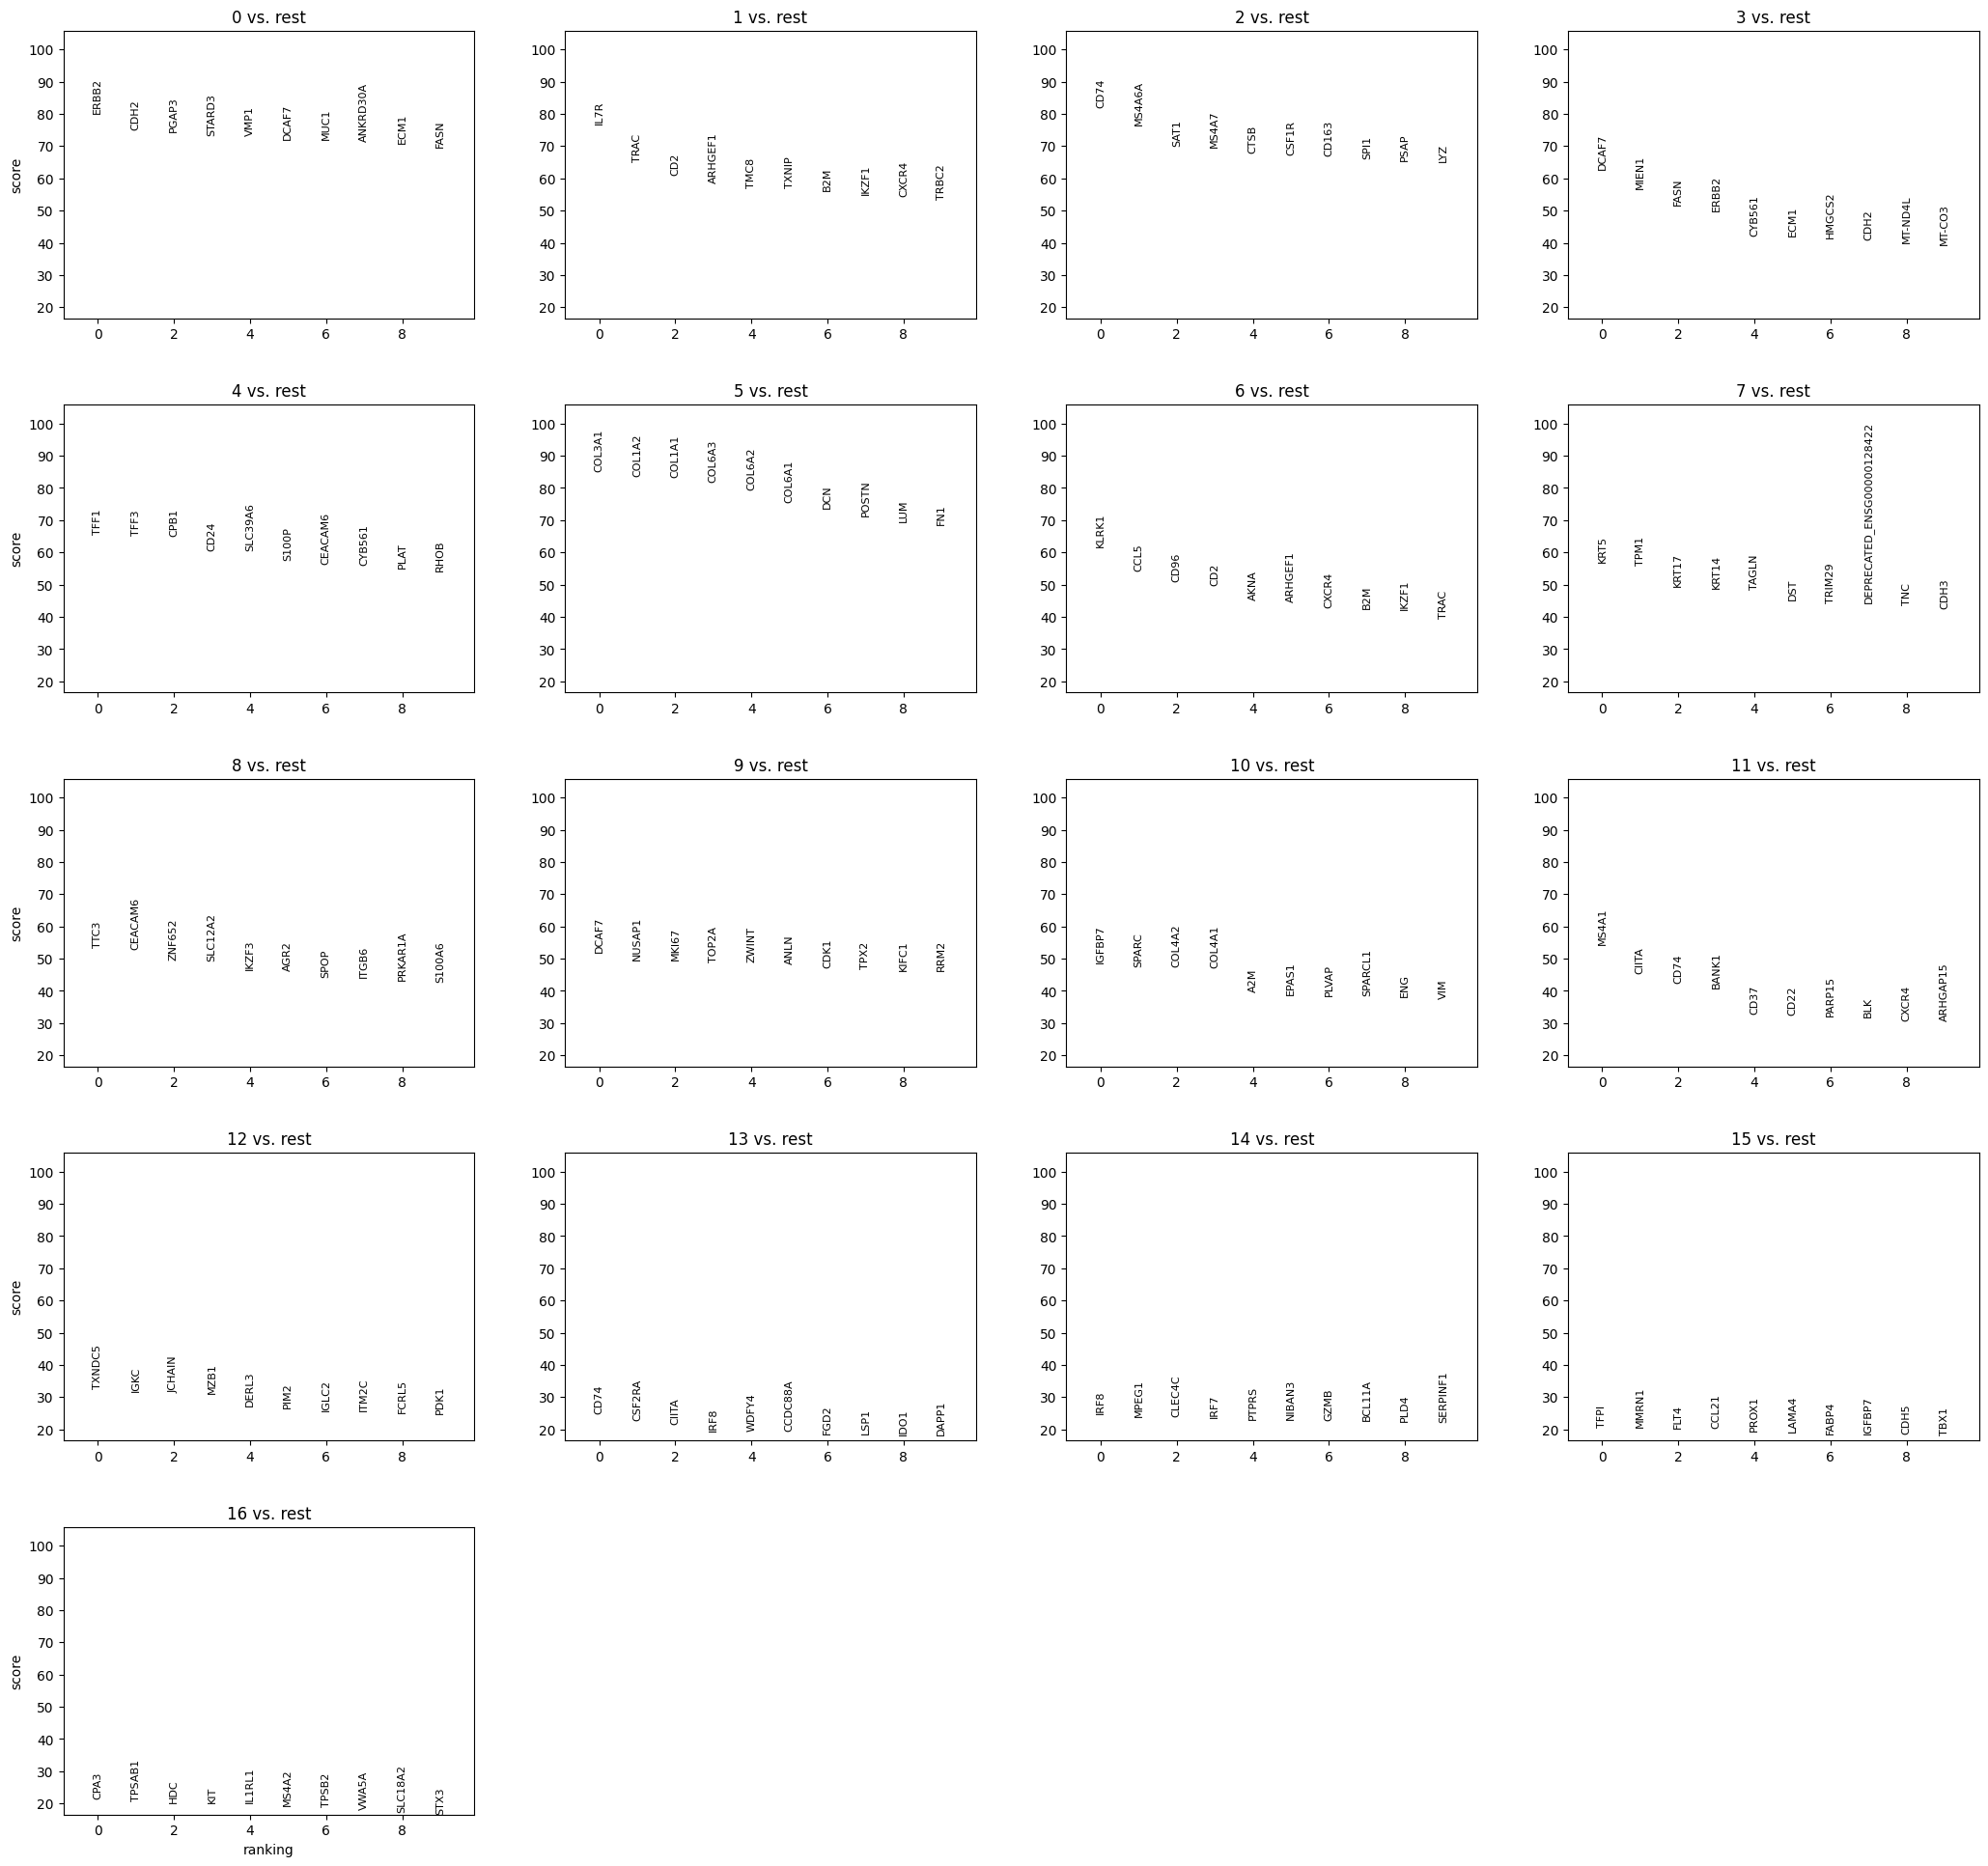

In [11]:
sc.tl.rank_genes_groups(adata, 'leiden', method='wilcoxon')
sc.pl.rank_genes_groups(adata, n_genes=10, save='_marker_genes.png')

# Cell 6c — Annotate cell types

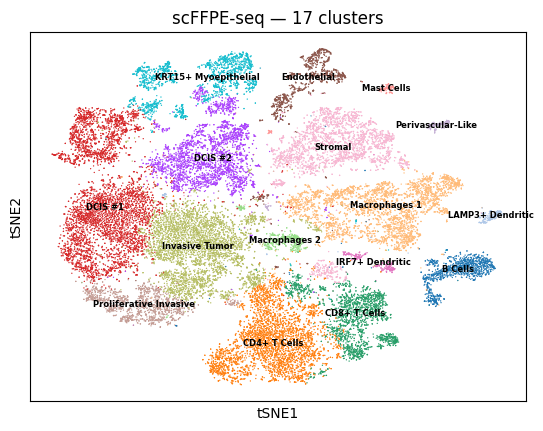

In [12]:
cell_type_markers = {
    'ACTA2+ Myoepithelial':   ['ACTA2'],
    'KRT15+ Myoepithelial':   ['KRT15'],
    'DCIS #1':                ['SCGB2A2'],
    'DCIS #2':                ['CPB1'],
    'Proliferative Invasive': ['MKI67', 'TOP2A'],
    'Invasive Tumor':         ['CDH2', 'FASN'],
    'Stromal':                ['SFRP2', 'POSTN'],
    'Endothelial':            ['VWF'],
    'Perivascular-Like':      ['RGS5'],
    'Mast Cells':             ['TPSAB1'],
    'Macrophages 1':          ['LYZ', 'IFI30', 'ITGAX'],
    'Macrophages 2':          ['SELENOP', 'F13A1', 'RNASE1'],
    'LAMP3+ Dendritic':       ['LAMP3'],
    'CD4+ T Cells':           ['CD4', 'TRAC'],
    'CD8+ T Cells':           ['CD8A', 'CD8B'],
    'IRF7+ Dendritic':        ['IRF7'],
    'B Cells':                ['MS4A1', 'BANK1'],
}

cluster_to_celltype = {
    '0':  'Invasive Tumor',
    '1':  'CD4+ T Cells',
    '2':  'Macrophages 1',
    '3':  'DCIS #1',
    '4':  'DCIS #2',
    '5':  'Stromal',
    '6':  'CD8+ T Cells',
    '7':  'KRT15+ Myoepithelial',
    '8':  'DCIS #1',
    '9':  'Proliferative Invasive',
    '10': 'Endothelial',
    '11': 'B Cells',
    '12': 'Macrophages 2',
    '13': 'IRF7+ Dendritic',
    '14': 'LAMP3+ Dendritic',
    '15': 'Perivascular-Like',
    '16': 'Mast Cells',
}

adata.obs['cell_type'] = adata.obs['leiden'].map(cluster_to_celltype)

sc.pl.tsne(adata, color='cell_type', legend_loc='on data',
           legend_fontsize=6, title='scFFPE-seq — 17 clusters',
           save='_fig2a_tsne.png')

# Cell 7a — Save annotated AnnData

In [13]:
output_path = '/content/drive/MyDrive/member1_scrna/outputs/annotated_adata.h5ad'
adata.write(output_path)
print(f"Saved to: {output_path}")
print(f"Shape: {adata.shape}")
print(f"Cell type counts:\n{adata.obs['cell_type'].value_counts()}")
print(f"Embeddings stored: {list(adata.obsm.keys())}")

Saved to: /content/drive/MyDrive/member1_scrna/outputs/annotated_adata.h5ad
Shape: (32498, 2758)
Cell type counts:
cell_type
DCIS #1                   5225
Invasive Tumor            4209
CD4+ T Cells              3900
Macrophages 1             3687
DCIS #2                   3094
Stromal                   3076
CD8+ T Cells              2160
KRT15+ Myoepithelial      1877
Proliferative Invasive    1487
Endothelial               1209
B Cells                   1191
Macrophages 2              490
IRF7+ Dendritic            294
LAMP3+ Dendritic           240
Perivascular-Like          204
Mast Cells                 155
Name: count, dtype: int64
Embeddings stored: ['X_pca', 'X_tsne']


# Cell 7b — Verify the file is complete

In [14]:
import scanpy as sc

test = sc.read(output_path)
assert 'cell_type' in test.obs.columns, "Missing cell_type annotation"
assert 'X_pca'    in test.obsm,         "Missing PCA"
assert 'X_tsne'   in test.obsm,         "Missing t-SNE"
print("All checks passed. File is ready for Member 2 and Member 4.")
print(f"Cell types found: {sorted(test.obs['cell_type'].unique())}")

All checks passed. File is ready for Member 2 and Member 4.
Cell types found: ['B Cells', 'CD4+ T Cells', 'CD8+ T Cells', 'DCIS #1', 'DCIS #2', 'Endothelial', 'IRF7+ Dendritic', 'Invasive Tumor', 'KRT15+ Myoepithelial', 'LAMP3+ Dendritic', 'Macrophages 1', 'Macrophages 2', 'Mast Cells', 'Perivascular-Like', 'Proliferative Invasive', 'Stromal']
